In [102]:
import schemdraw
import schemdraw.elements as elm
from schemdraw.segments import Segment, SegmentText  # <--- The Fix

In [128]:
class ArduinoUno(elm.Element):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        pin_separation = 0.4
        pin_font_size = 6.5

        height = 14*pin_separation + pin_separation/2

        width = 4
        
        # 1. Draw the main rectangle (The Body)
        self.segments.append(Segment([(0, 0), (width, 0), (width, height), (0, height), (0, 0)]))
        
        # 2. Add the Label in the middle
        self.anchors['center'] = (width/2, height/2)
        self.segments.append(SegmentText((width/2, height/2), 'Arduino Uno'))


        # Digital pins
        for i in range(13):
            name = f"D{i+1}"
            y = pin_separation*(i + 1)

            self.anchors[name] = (0, y)
            self.segments.append(Segment([(0, y), (-0.2, y)]))
            self.segments.append(SegmentText((0.2, y), name, align=('left', 'center'), fontsize=pin_font_size))

        # Analog pins
        for i in range(5):
            name = f"A{i+1}"
            y = pin_separation*(i + 1)

            self.anchors[name] = (width, y)
            self.segments.append(Segment([(width, y), (width + 0.2, y)]))
            self.segments.append(SegmentText((width - 0.2, y), name, align=('right', 'center'), fontsize=pin_font_size))
        


        # 4. Define Power Pins (Top Side)
        pins_top = ["GND", "5V", "3.3V"]
        for i,name in enumerate(pins_top):
            x = (i + 1)*width/(len(pins_top) + 1)
            self.anchors[name] = (x, height)
            self.segments.append(Segment([(x, height), (x, height + 0.2)]))
            self.segments.append(SegmentText((x, height - 0.2), name, align=('center', 'center'), fontsize=pin_font_size))

class MAX30102(elm.Element):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        title = "GY-MAX30102"

        pins_top = ["INT", "SDA", "SCL", "GND", "VIN"]

        pin_separation = 0.6
        pin_font_size = 6.5

        height = 2

        width = pin_separation*(len(pins_top) + 1)
        
    
        # 1. Draw the main rectangle (The Body)
        self.segments.append(Segment([(0, 0), (width, 0), (width, height), (0, height), (0, 0)]))
        

        # 2. Add the Label in the middle
        self.anchors['center'] = (width/2, height/2)
        self.segments.append(SegmentText((width/2, height/2), title))

        for i,name in enumerate(pins_top):
            x = (i + 1)*width/(len(pins_top) + 1)
            self.anchors[name] = (x, height)
            self.segments.append(Segment([(x, height), (x, height + 0.2)]))
            self.segments.append(SegmentText((x, height - 0.2), name, align=('center', 'center'), fontsize=pin_font_size))

class LCD1602(elm.Element):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        title = "LCD1602"

        pins_top = ["VSS",
            "VCC",
            "VEE",
            "RS",
            "R/W",
            "E",
            "D0",
            "D1",
            "D2",
            "D3",
            "D4",
            "D5",
            "D6",
            "D7",
            "A",
            "K"
        ]


        pin_separation = 0.5
        pin_font_size = 6.5

        height = 2

        width = pin_separation*(len(pins_top) + 1)
        
    
        # 1. Draw the main rectangle (The Body)
        self.segments.append(Segment([(0, 0), (width, 0), (width, height), (0, height), (0, 0)]))
        

        # 2. Add the Label in the middle
        self.anchors['center'] = (width/2, height/2)
        self.segments.append(SegmentText((width/2, height/2), title))

        for i,name in enumerate(pins_top):
            x = (i + 1)*width/(len(pins_top) + 1)
            self.anchors[name] = (x, height)
            self.segments.append(Segment([(x, height), (x, height + 0.2)]))
            self.segments.append(SegmentText((x, height - 0.2), name, align=('center', 'center'), fontsize=pin_font_size))


dict_keys(['center', 'INT', 'SDA', 'SCL', 'GND', 'VIN'])


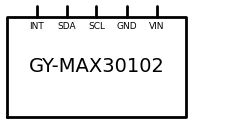

In [127]:
# --- THE ACTUAL DRAWING ---
with schemdraw.Drawing() as d:
    d.config(unit=1.2, fontsize=10)
    d += (UNO := MAX30102())

    print(UNO.anchors.keys())
    
    # Let's test a logical connection! 
    #d += elm.Line().left().at(UNO.D12).length(1).label('To LCD RS', 'left')

In [124]:
class LCD1602(elm.Element):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        title = "LCD1602"

        pins_top = ["VSS",
            "VCC",
            "VEE",
            "RS",
            "R/W",
            "E",
            "D0",
            "D1",
            "D2",
            "D3",
            "D4",
            "D5",
            "D6",
            "D7",
            "A",
            "K"
        ]


        pin_separation = 0.5
        pin_font_size = 6.5

        height = 2

        width = pin_separation*(len(pins_top) + 1)
        
    
        # 1. Draw the main rectangle (The Body)
        self.segments.append(Segment([(0, 0), (width, 0), (width, height), (0, height), (0, 0)]))
        

        # 2. Add the Label in the middle
        self.anchors['center'] = (width/2, height/2)
        self.segments.append(SegmentText((width/2, height/2), title))

        for i,name in enumerate(pins_top):
            x = (i + 1)*width/(len(pins_top) + 1)
            self.anchors[name] = (x, height)
            self.segments.append(Segment([(x, height), (x, height + 0.2)]))
            self.segments.append(SegmentText((x, height - 0.2), name, align=('center', 'center'), fontsize=pin_font_size))


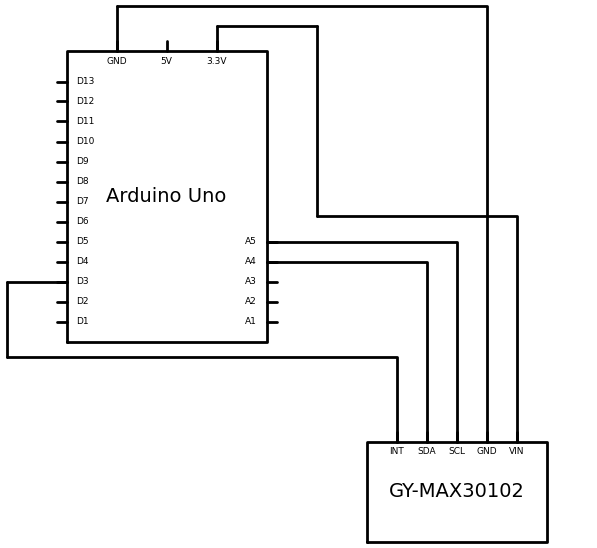

In [189]:
# --- THE ACTUAL DRAWING ---
with schemdraw.Drawing() as d:
    d.config(unit=1.2, fontsize=10)

    # 1. Place the blocks first
    d += (Uno := ArduinoUno().at((0,0)))
    d += (Sensor := MAX30102().at((6, -4))) # Placed up and to the right

    # 2. SDA Connection: Right then Up
    # We use 'dot()' to show the connection point clearly
    d += elm.RightLines().at(Uno.A4).to(Sensor.SDA)

    # 3. SCL Connection: Right then Up (placed slightly differently to avoid overlap)
    d += elm.RightLines().at(Uno.A5).to(Sensor.SCL)

    d += elm.Line().at(Uno.D3).left()
    d += elm.Line().down().length(1.5)
    d += elm.RightLines().to(Sensor.INT)

    d += elm.Line().at(Uno.GND).up().length(.9)
    d += elm.RightLines().to(Sensor.GND)

    d += elm.Line().at(Uno["3.3V"]).up().length(.5)
    d += elm.Line().right().length(2)
    d += elm.Line().down().length(3.8)
    d += elm.RightLines().to(Sensor.VIN)


    

    
    # Let's test a logical connection! 
    #d += elm.Line().left().at(Uno.D12).length(1).label('To LCD RS', 'left')